# Common Task 1.2 - Dataset Preprocessing for Squared Amplitude Calculation

Preprocessing the SYMBA dataset (17 files, QED + QCD) for sequence-to-sequence modeling.
- Parse raw data into amplitude / squared amplitude pairs
- Normalize Lorentz indices per sample
- Tokenize with a domain-specific word-level tokenizer
- 80-10-10 train/val/test split

In [ ]:
# clone repo and install deps
!git clone https://github.com/invi-bhagyesh/jepa.git 2>/dev/null || echo "already cloned"
%cd jepa
!pip install -q -r requirements.txt

In [1]:
import subprocess
from pathlib import Path

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

BOX_FILE_IDS = {
    "QED-2-to-2-diag-TreeLevel-0.txt": "2140788181255",
    "QED-2-to-2-diag-TreeLevel-1.txt": "2140796058577",
    "QED-2-to-2-diag-TreeLevel-2.txt": "2140784121230",
    "QED-2-to-2-diag-TreeLevel-3.txt": "2140795684607",
    "QED-2-to-2-diag-TreeLevel-4.txt": "2140797001951",
    "QED-2-to-2-diag-TreeLevel-5.txt": "2140790956723",
    "QED-2-to-2-diag-TreeLevel-6.txt": "2140783227753",
    "QED-2-to-2-diag-TreeLevel-7.txt": "2140782375969",
    "QED-2-to-2-diag-TreeLevel-8.txt": "2140786856895",
    "QED-2-to-2-diag-TreeLevel-9.txt": "2140788342997",
    "QCD-2-to-2-diag-TreeLevel-0.txt": "2140783153353",
    "QCD-2-to-2-diag-TreeLevel-1.txt": "2140782150182",
    "QCD-2-to-2-diag-TreeLevel-2.txt": "2140784051679",
    "QCD-2-to-2-diag-TreeLevel-3.txt": "2140782537477",
    "QCD-2-to-2-diag-TreeLevel-4.txt": "2140787761297",
    "QCD-2-to-2-diag-TreeLevel-5.txt": "2140785457220",
    "QCD-2-to-2-diag-TreeLevel-6.txt": "2140790024960",
}

SHARED_LINK = "https://alabama.box.com/s/xhgr2onrn503jyse2fs5vxtapg0oifcs"

existing = list(DATA_DIR.glob("*.txt"))
if len(existing) >= 17:
    print(f"All {len(existing)} files already present")
else:
    print("Downloading 17 data files from Box...")
    for name, fid in BOX_FILE_IDS.items():
        dest = DATA_DIR / name
        if dest.exists():
            continue
        url = f"https://dl.boxcloud.com/api/2.0/files/{fid}/content?shared_link={SHARED_LINK}"
        try:
            subprocess.run(
                ["wget", "-q", "--header", f"BoxApi: shared_link={SHARED_LINK}",
                 f"https://api.box.com/2.0/files/{fid}/content", "-O", str(dest)],
                check=True, timeout=30
            )
        except Exception:
            pass
        if not dest.exists() or dest.stat().st_size < 100:
            print(f"  auto-download failed for {name}")
            print(f"  >> download manually from: {SHARED_LINK}")
            print(f"  >> place all 17 .txt files in {DATA_DIR}/")
            break
    else:
        print(f"Downloaded {len(list(DATA_DIR.glob('*.txt')))} files")

print(f"\nFiles in {DATA_DIR}:")
for f in sorted(DATA_DIR.glob("*.txt")):
    print(f"  {f.name} ({f.stat().st_size / 1024:.0f} KB)")

  auto-download failed for QED-2-to-2-diag-TreeLevel-0.txt
  >> download manually from: https://alabama.box.com/s/xhgr2onrn503jyse2fs5vxtapg0oifcs
  >> place all 17 .txt files in data/raw/

Files in data/raw:
  QED-2-to-2-diag-TreeLevel-0.txt (0 KB)


In [3]:
%cd ..

/workspace/jepa


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data.download import validate_dataset
from src.data.parse import parse_all
from src.data.normalize import normalize_indices, normalize_dataframe
from src.data.tokenizer import PhysicsTokenizer
from src.data.dataset import build_splits, AmplitudeDataset, get_loader

## 1. Load and Parse Raw Data

Each row in the 17 data files follows the format:
```
interaction : Feynman diagram : amplitude : squared_amplitude
```
We extract amplitude (input) and squared amplitude (target) sequences.

In [5]:
files = validate_dataset("data/raw")
print(f"Found {len(files)} data files")
for f in files[:3]:
    print(f"  {f.name}")
print("  ...")

Found 17 data files
  QCD-2-to-2-diag-TreeLevel-0.txt
  QCD-2-to-2-diag-TreeLevel-1.txt
  QCD-2-to-2-diag-TreeLevel-2.txt
  ...


In [6]:
df = parse_all("data/raw")
print(f"Total samples: {len(df)}")
print(f"\nSamples per physics model:")
print(df["physics_model"].value_counts().to_string())
print(f"\nSample row:")
print(df.iloc[0].to_string())

Parsing: 100%|██████████| 17/17 [00:00<00:00, 133.68it/s]

Total samples: 594

Samples per physics model:
physics_model
QED    360
QCD    234

Sample row:
interaction          Interaction:  u_{G_49,eps_42}(X)^(*)  AntiPart...
feynman_diagram      Vertex V_1:d(X_3), AntiPart d(X_4),  OffShell ...
amplitude            -1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_1...
squared_amplitude    -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_1...
physics_model                                                      QCD
source_file                            QCD-2-to-2-diag-TreeLevel-0.txt


## 2. Index Normalization

Indices like `_45`, `_112` grow globally across the dataset. We remap them to `_1`, `_2`, ... per sample. Amplitude and squared amplitude share the same index space within a sample, so normalization is applied jointly to preserve correspondence.

In [7]:
# demonstrate on a single sample before/after
row = df.iloc[0]
print("BEFORE normalization:")
print(f"  amplitude:         {row['amplitude'][:120]}...")
print(f"  squared_amplitude: {row['squared_amplitude'][:120]}...")

na, ns = normalize_indices(row["amplitude"], row["squared_amplitude"])
print("\nAFTER normalization:")
print(f"  amplitude:         {na[:120]}...")
print(f"  squared_amplitude: {ns[:120]}...")

BEFORE normalization:
  amplitude:         -1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_55,%gam_115}(p_3)_u^...
  squared_amplitude: -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2...

AFTER normalization:
  amplitude:         -1/4*i*g^2*gamma_{+%\sigma_1,%gam_2,%del_2}*gamma_{%\sigma_1,%gam_3,%del_3}*(d_{j_4,%C_5,%gam_2}(p_6)_u^(*)*d_{k_4,%D_7,...
  squared_amplitude: -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_14 + (-8)*s_15*s_16 + (-8)*s_17*s_18 + (-8)*m_u^2*s_19)*(m_u^2 + s_14 + 1/2...


In [8]:
df = normalize_dataframe(df)
print(f"Normalized {len(df)} samples")

Normalized 594 samples


## 3. Tokenization

We use a **word-level tokenizer** with physics-aware regex rules. Each token maps to one physical quantity or operator.

**Why not character-level?** Multi-character symbols like `g_s` or `gamma_mu` would be split into meaningless characters, wasting sequence length.

**Why not BPE?** The physics vocabulary is finite (~50-150 tokens). BPE merges would destroy physical semantics - e.g., merging `gamma` with `_` into a subword that doesn't correspond to any quantity.

**Why word-level?** Each token = one operator, symbol, index, or number. Sequences stay short and semantically meaningful. This follows Lample & Charton (2019) who used domain-specific tokenization for symbolic math transformers.

In [9]:
tokenizer = PhysicsTokenizer()

# build vocab from all expressions (amplitudes + squared amplitudes)
all_exprs = df["amplitude"].tolist() + df["squared_amplitude"].tolist()
tokenizer.build_vocab(all_exprs)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"\nSample tokens (first 30):")
for i in range(min(30, tokenizer.vocab_size)):
    print(f"  {i}: '{tokenizer.id2token[i]}'")

Vocabulary size: 1095

Sample tokens (first 30):
  0: '<PAD>'
  1: '<SOS>'
  2: '<EOS>'
  3: '<UNK>'
  4: '*'
  5: '('
  6: ')'
  7: ','
  8: '+'
  9: '{'
  10: '}'
  11: '2'
  12: '1/2'
  13: 'i'
  14: 'reg_prop'
  15: 'g'
  16: '/'
  17: 'gamma_'
  18: 's_86'
  19: '-'
  20: '-1/2'
  21: '_u'
  22: '_v'
  23: 'G_'
  24: 'T_C_6_'
  25: 'm_u'
  26: 'e'
  27: 's_16'
  28: 'p_1'
  29: 's_87'


In [10]:
# tokenize + decode round-trip check
sample_expr = df.iloc[0]["amplitude"]
tokens = tokenizer.tokenize(sample_expr)
ids = tokenizer.encode(sample_expr)
decoded = tokenizer.decode(ids)

print(f"Original:  {sample_expr[:100]}...")
print(f"Tokens:    {tokens[:15]}...")
print(f"IDs:       {ids[:15]}...")
print(f"Decoded:   {decoded[:100]}...")

Original:  -1/4*i*g^2*gamma_{+%\sigma_1,%gam_2,%del_2}*gamma_{%\sigma_1,%gam_3,%del_3}*(d_{j_4,%C_5,%gam_2}(p_6...
Tokens:    ['-1/4', '*', 'i', '*', 'g', '2', '*', 'gamma_', '{', '+', 'sigma_1', ',', 'gam_2', ',', 'del_2']...
IDs:       [1, 265, 4, 13, 4, 15, 11, 4, 17, 9, 8, 120, 7, 104, 7]...
Decoded:   -1/4 * i * g 2 * gamma_ { + sigma_1 , gam_2 , del_2 } * gamma_ { sigma_1 , gam_3 , del_3 } * ( d_ { ...


## 4. Train/Val/Test Split and Statistics

In [11]:
train_df, val_df, test_df = build_splits(df, seed=42)

print("Split sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Val:   {len(val_df)}")
print(f"  Test:  {len(test_df)}")

print("\nPer-model distribution:")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split["physics_model"].value_counts()
    print(f"  {name}: QED={counts.get('QED', 0)}, QCD={counts.get('QCD', 0)}")

Split sizes:
  Train: 475
  Val:   59
  Test:  60

Per-model distribution:
  Train: QED=289, QCD=186
  Val: QED=33, QCD=26
  Test: QED=38, QCD=22


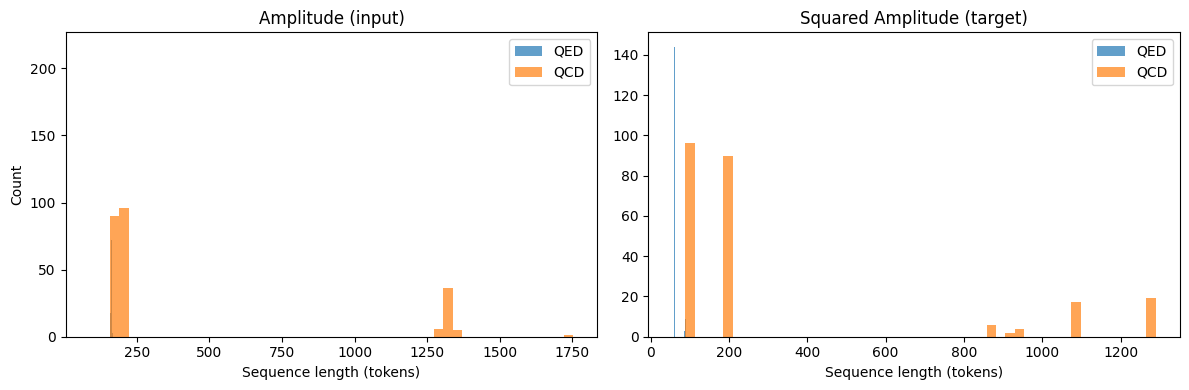


Amplitude lengths  -- mean: 238, max: 1753, median: 161
Sq. Amp. lengths   -- mean: 179, max: 1290, median: 91


In [12]:
import numpy as np

src_lens = [len(tokenizer.encode(e)) for e in df["amplitude"]]
tgt_lens = [len(tokenizer.encode(e)) for e in df["squared_amplitude"]]

qed_mask = df["physics_model"] == "QED"
qcd_mask = df["physics_model"] == "QCD"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist([l for l, m in zip(src_lens, qed_mask) if m], bins=50, alpha=0.7, label="QED")
axes[0].hist([l for l, m in zip(src_lens, qcd_mask) if m], bins=50, alpha=0.7, label="QCD")
axes[0].set_xlabel("Sequence length (tokens)")
axes[0].set_ylabel("Count")
axes[0].set_title("Amplitude (input)")
axes[0].legend()

axes[1].hist([l for l, m in zip(tgt_lens, qed_mask) if m], bins=50, alpha=0.7, label="QED")
axes[1].hist([l for l, m in zip(tgt_lens, qcd_mask) if m], bins=50, alpha=0.7, label="QCD")
axes[1].set_xlabel("Sequence length (tokens)")
axes[1].set_title("Squared Amplitude (target)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAmplitude lengths  -- mean: {np.mean(src_lens):.0f}, max: {max(src_lens)}, median: {np.median(src_lens):.0f}")
print(f"Sq. Amp. lengths   -- mean: {np.mean(tgt_lens):.0f}, max: {max(tgt_lens)}, median: {np.median(tgt_lens):.0f}")

### Verify DataLoader

In [13]:
loader = get_loader(train_df, tokenizer, batch_size=4, shuffle=False)
src_batch, tgt_batch = next(iter(loader))
print(f"Source batch shape: {src_batch.shape}")
print(f"Target batch shape: {tgt_batch.shape}")

# decode first sample back
print(f"\nDecoded source[0]: {tokenizer.decode(src_batch[0].tolist())[:100]}...")
print(f"Decoded target[0]: {tokenizer.decode(tgt_batch[0].tolist())[:100]}...")

Source batch shape: torch.Size([4, 1324])
Target batch shape: torch.Size([4, 1078])

Decoded source[0]: i * g 2 * ( p_1_ tau_2 * gamma_ { sigma_3 , gam_4 , del_5 } * T_C_6_ { a_7 , D_8 , B_9 } * T_C_6_ { ...
Decoded target[0]: 4/9 * g 4 * s_29 * s_30 * ( s_28 + -1/2 * reg_prop ) ( -2 ) + -8/9 * i * g 2 * ( i * g 2 * m_u 2 * (...


In [14]:
from pathlib import Path
Path("data/processed").mkdir(parents=True, exist_ok=True)

tokenizer.save("data/processed/vocab.txt")
train_df.to_csv("data/processed/train.csv", index=False)
val_df.to_csv("data/processed/val.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)
print("Saved tokenizer vocab and splits to data/processed/")

Saved tokenizer vocab and splits to data/processed/
